## Importando bibliotecas

In [34]:
import csv
import json
from datetime import datetime


## Definindo constraints

In [35]:
LIMITE_SUSPEITO = 10000.00

## Função para validar uma transação

In [36]:
def validar_transacao(linha):
    try:
        if not linha["id"].isdigit():
            return None

        if not linha["cliente_id"].strip():
            return None

        try:
            data = datetime.strptime(
                linha["data"],
                "%Y-%m-%d"
            )
        except ValueError:
            return None

        tipo = linha["tipo"].lower()

        if tipo not in ["credito", "debito"]:
            return None

        try:
            valor = float(linha["valor"])
        except ValueError:
            return None

        if valor <= 0:
            return None

        return {
            "id": int(linha["id"]),
            "data": data,
            "cliente_id": linha["cliente_id"],
            "tipo": tipo,
            "valor": valor,
            "descricao": linha["descricao"],
            "categoria": linha["categoria"]
        }

    except KeyError:
        return None

## Função para ler o CSV

In [37]:
def ler_transacoes(nome_arquivo):
    transacoes_validas = []
    total_lidas = 0
    total_invalidas = 0

    try:
        with open(nome_arquivo, "r", encoding="utf-8") as arquivo:
            leitor = csv.DictReader(arquivo)

            for linha in leitor:
                total_lidas += 1

                transacao = validar_transacao(linha)

                if transacao:
                    transacoes_validas.append(transacao)
                else:
                    total_invalidas += 1

    except FileNotFoundError:
        print(f"Arquivo '{nome_arquivo}' não encontrado.")
        return [], 0, 0

    return transacoes_validas, total_lidas, total_invalidas

## Testando a leitura

In [38]:
transacoes, total_lidas, total_invalidas = ler_transacoes("transacoes.csv")

print("Total lidas:", total_lidas)
print("Inválidas:", total_invalidas)
print("Válidas:", len(transacoes))

Total lidas: 21
Inválidas: 5
Válidas: 16


## Gerando relatório mensal

In [39]:
def gerar_relatorio(transacoes):
    resumo = {}

    for t in transacoes:

        mes = t["data"].strftime("%Y-%m")

        if mes not in resumo:
            resumo[mes] = {
                "quantidade": 0,
                "total_credito": 0,
                "total_debito": 0,
                "maior": t["valor"],
                "menor": t["valor"]
            }

        resumo[mes]["quantidade"] += 1

        if t["tipo"] == "credito":
            resumo[mes]["total_credito"] += t["valor"]
        else:
            resumo[mes]["total_debito"] += t["valor"]

        resumo[mes]["maior"] = max(
            resumo[mes]["maior"],
            t["valor"]
        )

        resumo[mes]["menor"] = min(
            resumo[mes]["menor"],
            t["valor"]
        )

    for mes, dados in resumo.items():

        saldo = (
            dados["total_credito"]
            - dados["total_debito"]
        )

        media = (
            (dados["total_credito"] +
             dados["total_debito"])
            / dados["quantidade"]
        )

        dados["saldo"] = saldo
        dados["media"] = media

    return resumo

## Encontrando transações suspeitas

In [40]:
def identificar_suspeitas(transacoes):
    suspeitas = []

    for t in transacoes:
        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append(t)

    return suspeitas

## Função para formatar dinheiro

In [41]:
def moeda(valor):
    return f"R$ {valor:,.2f}".replace(
        ",", "X"
    ).replace(
        ".", ","
    ).replace(
        "X", "."
    )

## Exibindo relatório

In [48]:
def exibir_relatorio(
    resumo,
    suspeitas,
    validas,
    invalidas,
    transacoes
):

    print("\n===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {validas + invalidas}")
    print(f"Linhas válidas: {validas}")
    print(f"Linhas inválidas: {invalidas}")

    datas = [t["data"] for t in transacoes]

    mais_antiga = min(datas)
    mais_recente = max(datas)

    dias = (mais_recente - mais_antiga).days

    print("=" * 40)
    print("RELATÓRIO FINANCEIRO")
    print("=" * 40)

    print(
        f"Período: "
        f"{mais_antiga.strftime('%Y-%m-%d')} "
        f"até "
        f"{mais_recente.strftime('%Y-%m-%d')}"
    )

    print(f"Dias analisados: {dias}")
    print(f"Transações válidas: {validas}")
    print(f"Transações inválidas: {invalidas}")

    print("\n===== RELATÓRIO MENSAL =====")

    for mes, dados in sorted(resumo.items()):

        print(f"\nMês: {mes}")

        print(f"  Transações: {dados['quantidade']}")
        print(f"  Crédito: {moeda(dados['total_credito'])}")
        print(f"  Débito: {moeda(dados['total_debito'])}")
        print(f"  Saldo: {moeda(dados['saldo'])}")
        print(f"  Média: {moeda(dados['media'])}")
        print(f"  Maior valor: {moeda(dados['maior'])}")
        print(f"  Menor valor: {moeda(dados['menor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")

    if suspeitas:

        for t in suspeitas:
            print(
                f"ID: {t['id']} | "
                f"Cliente: {t['cliente_id']} | "
                f"Data: {t['data'].strftime('%Y-%m-%d')} | "
                f"Valor: {moeda(t['valor'])}"
            )

    else:
        print("Nenhuma transação suspeita encontrada.")

## Salvando JSON

In [43]:
def salvar_json(
    resumo,
    validas,
    invalidas
):

    relatorio = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": validas,
        "total_transacoes_invalidas": invalidas,
        "resumo_mensal": resumo
    }

    with open(
        "relatorio.json",
        "w",
        encoding="utf-8"
    ) as arquivo:

        json.dump(
            relatorio,
            arquivo,
            ensure_ascii=False,
            indent=2
        )



## Célula principal

In [49]:
transacoes, total_lidas, total_invalidas = ler_transacoes(
    "transacoes.csv"
)

resumo = gerar_relatorio(transacoes)

suspeitas = identificar_suspeitas(transacoes)

exibir_relatorio(
    resumo,
    suspeitas,
    len(transacoes),
    total_invalidas,
    transacoes
)

resumo_json = {}

for mes, dados in resumo.items():
    resumo_json[mes] = dados

salvar_json(
    resumo_json,
    len(transacoes),
    total_invalidas
)


===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 21
Linhas válidas: 16
Linhas inválidas: 5
RELATÓRIO FINANCEIRO
Período: 2026-01-05 até 2026-04-25
Dias analisados: 110
Transações válidas: 16
Transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 4
  Crédito: R$ 4.700,00
  Débito: R$ 430,50
  Saldo: R$ 4.269,50
  Média: R$ 1.282,62
  Maior valor: R$ 3.500,00
  Menor valor: R$ 180,50

Mês: 2026-02
  Transações: 4
  Crédito: R$ 17.000,00
  Débito: R$ 770,00
  Saldo: R$ 16.230,00
  Média: R$ 4.442,50
  Maior valor: R$ 15.000,00
  Menor valor: R$ 320,00

Mês: 2026-03
  Transações: 4
  Crédito: R$ 5.300,00
  Débito: R$ 749,90
  Saldo: R$ 4.550,10
  Média: R$ 1.512,47
  Maior valor: R$ 3.500,00
  Menor valor: R$ 99,90

Mês: 2026-04
  Transações: 4
  Crédito: R$ 26.000,00
  Débito: R$ 730,00
  Saldo: R$ 25.270,00
  Média: R$ 6.682,50
  Maior valor: R$ 25.000,00
  Menor valor: R$ 310,00

===== TRANSAÇÕES SUSPEITAS =====
ID: 6 | Cliente: CLI003 | Data: 2026-02-14 

## Gráfico com Matplotlib

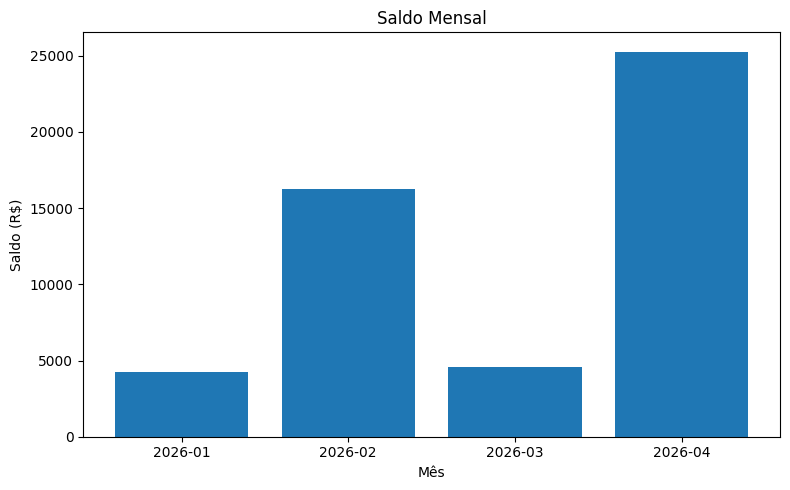

In [51]:
import matplotlib.pyplot as plt

meses = list(resumo.keys())
saldos = [dados["saldo"] for dados in resumo.values()]

plt.figure(figsize=(8,5))
plt.bar(meses, saldos)

plt.title("Saldo Mensal")
plt.xlabel("Mês")
plt.ylabel("Saldo (R$)")

plt.tight_layout()
plt.savefig("grafico.png")
plt.show()